# SCS 3546: Deep Learning
> Assignment 1: Deep Learning Using Keras

### Your name & student number:

<pre> Ievgen Tsygankov </pre>

<pre> X588947 </pre>

## Assignment Description

In this assignment you will demonstrate your ability to:

- Train a neural network using Keras to solve a regression problem.

- Perform sensible data preprocessing.

- Experiment with hyperparemter tuning and different model architectures to achieve best performance.



### Grade Allocation

**15 points total**

- Part 1: 4 Marks
- Part 2: 9 Marks
- Clarity: 2 Marks

The marks for clarity are awarded for code documentation and how well you explained/supported your answers, including the use of visualizations where appropriate.

In [1]:
# OPTIONAL : For model evaluation and for those who choose to use the KerasRegressor from keras.wrappers, you would need to install tensorflow 2.12 or 2.11.another option is to use the scikeras.
# please note that you may have many options and the below libraries are just meant to help you and to provide options

#!pip install tensorflow
# from keras.wrappers.scikit_learn import KerasRegressor


#!pip install scikeras
# !pip install --upgrade scikeras

#from scikeras.wrappers import KerasRegressor


In [2]:
# setting up the notebook with important libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
# from keras.models import Sequential
# from keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import layers
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from tensorflow.keras import Input

# Preamble

### Hyperparameters

A hyperparameter is a parameter whose value is set before the learning process begins.

Some important Neural Networks hyperparameters include:

- number of hidden layers
- number of neurons
- learning rate
- activation function
- optimizer settings

Hyperparameters are crucial to the performance, speed, and quality of the machine learning models.

Through Hyper parameter optimization, we find a tuple (best combination) of hyperparameters that yields an optimal model which minimizes a predefined loss function on given test data.

Important hyperparameters that could be tuned include:

- num_hidden_layers
- neurons_per_layer
- dropout_rate
- activation
- optimizer
- learning_rate
- batch_size

### Loss Function

- MSE (Mean Squared Error) is used as the score/loss function that will be minimized for hyperparameter optimization.
- In this assignment, we are going to use Cross-Validation to calculate the score (MSE) for a given set of hyperparameter values

- MSE is a desirable metric because by taking the square root gives us an error value we can directly understand in the context of the problem; for example, in this assignment it translates to thousands of dollars

- Note: Your results may vary given the stochastic nature of the algorithm, evaluation procedure, or differences in numerical precision

## Dataset

We will be using mock data for this assignment. the outcome is the sale price for some products. we have created 13 features to predict the sale price.

- import provided mock data into your notebook.

- You are **not** expected to perform Exploratory Data Analysis (EDA) on this dataset.

- For the purpose of this assignment, your model's performance is not an important factor by itself - that is how far your sale price prediction is. The important factor is the changes that you observe when changing model architectures.

- The information that follow are meant to be optional and to help you get familiar with the data. Your efforts on this assignment should focus on **model training and hyperparameter tuning**, not on EDA.


# Assignment Start
***

- Please follow all instructions carefully.

- Use MSE (Mean Squared Error) as the score/loss function that will be minimized during optimization.








#Data Import

The code below imports the data for you as dataframe, then you may need to convert it to numpy arrays.  

In [3]:
# You can use the code below to import the data

# Option 3 - from local using the files that are available
import pandas as pd

# mount the colab
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)


# Next, You need to upload tables to your G drive -  then you may need to update  paths below

base_path = '/content/gdrive/MyDrive/Colab Notebooks/SCS_3546_Deep Learning/001_Assignment-Deep Learning using Keras/'

# load the  data into a pandas dataframe for easy viewing and manipulation
df_train_y = pd.read_csv(base_path + "y_train.csv")
df_test_y = pd.read_csv(base_path + "y_test.csv")
df_train_x  =  pd.read_csv(base_path + "X_train.csv")
df_test_x =  pd.read_csv(base_path + "X_test.csv")

Mounted at /content/gdrive


#Check data shape

In [4]:
print("X_train shape:", df_train_x.shape)
print("y_train shape:", df_train_y.shape)
print("X_test shape:", df_test_x.shape)
print("y_test shape:", df_test_y.shape)

# df_train_x.head()
# df_train_y.head()

X_train shape: (404, 14)
y_train shape: (404, 2)
X_test shape: (102, 14)
y_test shape: (102, 2)


#Review the data


In [5]:
print("X_train sample:")
display(df_train_x.head())

print("y_train sample:")
display(df_train_y.head(15))

X_train sample:


,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72
1,1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11
2,2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26
3,3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01
4,4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65


y_train sample:


,Unnamed: 0,0
0,0,15.2
1,1,42.3
2,2,50.0
3,3,21.1
4,4,17.7
5,5,18.5
6,6,11.3
7,7,15.6
8,8,15.6
9,9,14.4


In [6]:
#Both data frames have additional/unnecessary index column. This is to be cleaned up.

#Clean up the data

In [7]:
# Drop index column from features
df_train_x = df_train_x.drop(columns=["Unnamed: 0"])
df_test_x = df_test_x.drop(columns=["Unnamed: 0"])

# Drop index column from targets, then convert to Series
df_train_y = df_train_y.drop(columns=["Unnamed: 0"])
df_test_y = df_test_y.drop(columns=["Unnamed: 0"])

In [8]:
#Verify shape of the data after clean-up
print("X_train shape:", df_train_x.shape)
print("y_train shape:", df_train_y.shape)
print("X_test shape:", df_test_x.shape)
print("y_test shape:", df_test_y.shape)

X_train shape: (404, 13)
y_train shape: (404, 1)
X_test shape: (102, 13)
y_test shape: (102, 1)


In [9]:
# Convert target from single-column DataFrame to Series -- > required for Keras
y_train = df_train_y.squeeze()
y_test = df_test_y.squeeze()

In [10]:
print("y_test:", y_test.shape)
print("y_train:", y_train.shape)

y_test: (102,)
y_train: (404,)


In [11]:
#Review data after transformation
print("X_train sample:")
display(df_train_x.head())

print("y_train sample:")
display(y_train.head())

X_train sample:


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72
1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11
2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26
3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01
4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65


y_train sample:


,0
0,15.2
1,42.3
2,50.0
3,21.1
4,17.7


#Scale Data (standardization)

In [12]:
# Hint : to make it easier, you may try to standardize your data upfront

In [13]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data, then transform both
X_train_scaled = scaler.fit_transform(df_train_x)
X_test_scaled = scaler.transform(df_test_x)

# Part 1: Impact of Changing Model Architecture

In this section, we will be comparing a simple single-layer baseline model with two other models having a different network topology.

## a) Baseline model [2 points]

Use Keras to develop a baseline neural network model that has **one single fully-connected hidden layer with the same number of neurons as input features (i.e. 13 neurons).**

Make sure to **standardize** your features (i.e. subtract mean and divide by standard deviation) before training your model. You can also perform any other data-preprocessing that you deem necessary.

- Note: No activation function is used for the output layer because it is a regression problem and we are interested in predicting numerical values directly without transformation.

- The ADAM optimization algorithm should be used to optimize mean squared error loss function.

- Plot learning curves and report on both training and validation performance.

###Build the baseline model

In [14]:
# Define input dimension
input_dim = X_train_scaled.shape[1]

# Build the model with layer list
baseline_model = keras.Sequential([
    Input(shape=(input_dim,)),                     # Input layer
    layers.Dense(13, activation='relu'),           # Hidden layer with 13 neurons
    layers.Dense(1)                                # Output layer with no activation (linear)
])


# Compile the model
baseline_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', 'mse']
)

# Show model summary
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 13)             │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196 (784.00 B)

 Trainable params: 196 (784.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Baseline Model Summary
  # Architecture:
      # Input layer: implied via input_shape=(13,)
      # Hidden layer: Dense(13, activation='relu')
      # Output layer: Dense(1) - no activation / linear output for regression

  # Layer description
      #Layer 1:
        #Type: Fully connected (Dense)
        #Output Shape: (None, 13) → outputs 13 values per sample
        #Params: 182
          #Formula: (inputs + bias) * units = (13 + 1) * 13 = 182
          #Each of the 13 neurons receives 13 inputs + 1 bias term

      #Layer 2:
          # Type: Output layer (Dense)
          # Output Shape: (None, 1) → predicts one value per sample (sale price)
          # Params: 14
            # Formula: 13 inputs * 1 unit + 1 bias = 13 + 1 = 14

###Train baseline model

In [16]:
np.random.seed(42)           #Ensure the shuffling inside fit() is reproducible
tf.random.set_seed(42)       #Ensure model weight initialization is consistent across runs

In [17]:
history_baseline = baseline_model.fit(
    X_train_scaled,          # Training features (scaled)
    y_train,                 # Target values
    validation_split=0.2,    # Use 20% of training data for validation
    epochs=100,              # Train for 100 full passes
    batch_size=32,           # Use mini-batches of 32 samples
    verbose=1                # Show progress bar during training
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 552.4363 - mae: 21.7056 - mse: 552.4363 - val_loss: 635.9736 - val_mae: 23.5577 - val_mse: 635.9736
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 544.5631 - mae: 21.5505 - mse: 544.5631 - val_loss: 627.6324 - val_mae: 23.3995 - val_mse: 627.6324
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 536.8822 - mae: 21.4008 - mse: 536.8822 - val_loss: 619.0801 - val_mae: 23.2369 - val_mse: 619.0801
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 529.0320 - mae: 21.2476 - mse: 529.0320 - val_loss: 610.4048 - val_mae: 23.0707 - val_mse: 610.4048
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 521.0104 - mae: 21.0907 - mse: 521.0104 - val_loss: 601.5776 - val_mae: 22.8986 - val_mse: 601.5776
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 512.8530 - mae: 20.9290 - mse: 512.8530 - val_loss: 592.5627 - val_mae: 22.7192 - val_mse: 592.5627
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 

###Plot Learning curves for baseline model

In [18]:
def plot_learning_curves(history, title_prefix="Baseline Model"):
    # Extract metrics
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(loss) + 1)

    # Plot MSE (loss)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='Train MSE')
    plt.plot(epochs, val_loss, label='Val MSE')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error')
    plt.title(f'{title_prefix} - MSE')
    plt.legend()
    plt.grid(True)

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(epochs, mae, label='Train MAE')
    plt.plot(epochs, val_mae, label='Val MAE')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Absolute Error')
    plt.title(f'{title_prefix} - MAE')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

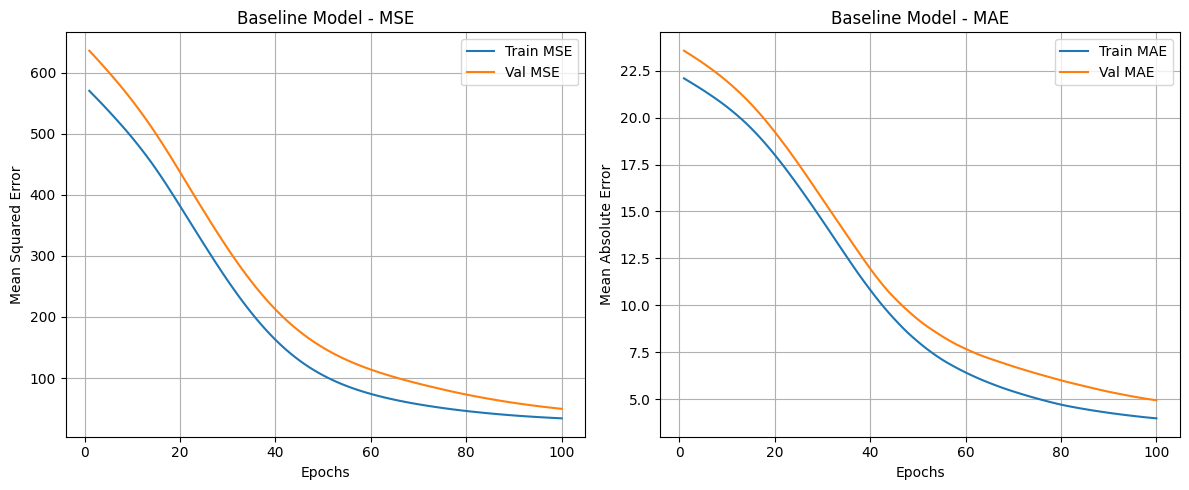

In [19]:
plot_learning_curves(history_baseline)

In [20]:
#Learning curve - Conclusions for baseline model

# MSE Curve (Loss Function)
  # Both training and validation MSE decrease steadily.
  # By epoch ~90, curves flatten and are close to each other.
  # Conclusion:
    # Model is learning well with no signs of overfitting.
    # Training is stable, and generalization is good.

# MAE Curve
  # MAE steadily declines for both train and val sets.
  # Validation MAE is slightly higher than training MAE — expected.
  # Conclusion:
    # Model predictions are improving steadily.
    # Final MAE is low, model performance is good.

## b) Deeper Network [1 point]

Construct and evaluate a model with 2 dense layers having a smaller number of neurons (e.g. 16, 8).

###Build Deeper Network Model

In [21]:
deeper_model = Sequential([
    Input(shape=(input_dim,)),          # Input layer with 13 features
    Dense(16, activation='relu'),       # Hidden layer 1 with 16 neurons and ReLU activation
    Dense(8, activation='relu'),        # Hidden layer 2 with 8 neurons and ReLU activation
    Dense(1)                            # Output layer with no activation (linear)
])

deeper_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', 'mse']
)

deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Deeper Model Summary
  # Architecture:
      # Input layer: implied via input_shape=(13,)
      # Hidden layer 1: Dense(16, activation='relu')
      # Hidden layer 2: Dense(8, activation='relu')
      # Output layer: Dense(1) - no activation / linear output for regression

  # Layer description
      # Layer 1:
          # Type: Fully connected (Dense)
          # Output Shape: (None, 16) → outputs 16 values per sample
          # Params: 224
            # Formula: (inputs + bias) * units = (13 + 1) * 16 = 224
            # Each of the 16 neurons receives 13 inputs + 1 bias term

      # Layer 2:
          # Type: Fully connected (Dense)
          # Output Shape: (None, 8) → outputs 8 values per sample
          # Params: 136
            # Formula: (16 + 1) * 8 = 136
            # Each of the 8 neurons receives 16 inputs + 1 bias term

      # Layer 3:
          # Type: Output layer (Dense)
          # Output Shape: (None, 1) → predicts one value per sample (sale price)
          # Params: 9
            # Formula: (8 + 1) * 1 = 9
            # Single output neuron receives 8 inputs + 1 bias term

  #Total trainable parameters: 369

###Train Deeper Network Model

In [23]:
history_deeper = deeper_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 563.5343 - mae: 21.9618 - mse: 563.5343 - val_loss: 647.4213 - val_mae: 23.7260 - val_mse: 647.4213
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 555.4263 - mae: 21.7488 - mse: 555.4263 - val_loss: 640.9452 - val_mae: 23.5777 - val_mse: 640.9452
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 549.3783 - mae: 21.5926 - mse: 549.3783 - val_loss: 635.7880 - val_mae: 23.4648 - val_mse: 635.7880
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 544.7070 - mae: 21.4751 - mse: 544.7070 - val_loss: 631.0511 - val_mae: 23.3629 - val_mse: 631.0511
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 540.2507 - mae: 21.3654 - mse: 540.2507 - val_loss: 625.8880 - val_mae: 23.2531 - val_mse: 625.8880
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 535.1425 - mae: 21.2424 - mse: 535.1425 - val_loss: 619.6584 - val_mae: 23.1204 - val_mse: 619.6584
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9m

###Plot Learning curves for Deeper Network Model

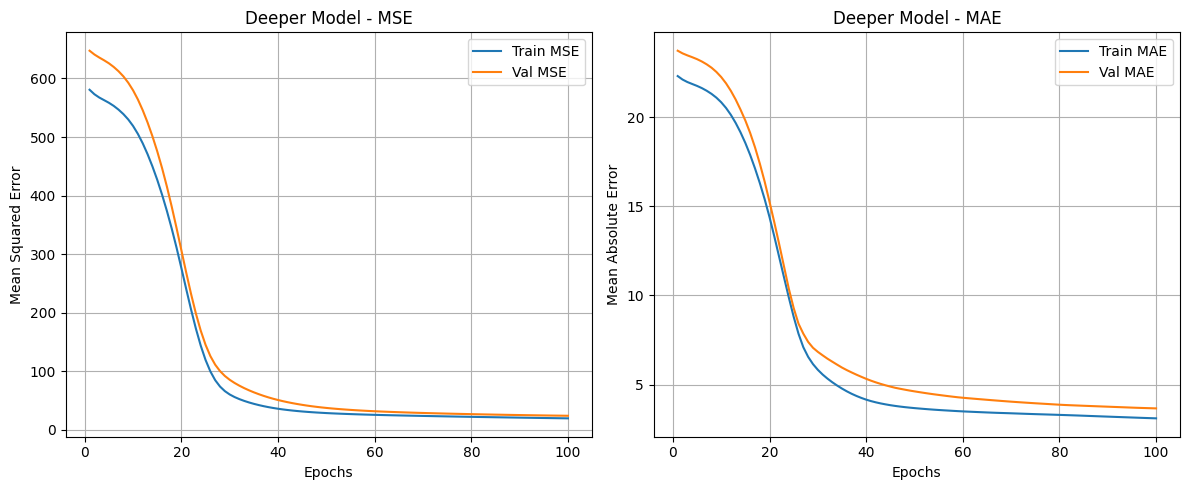

In [24]:
plot_learning_curves(history_deeper, title_prefix="Deeper Model")

In [25]:
# Learning Curve - Conclusions for Deeper Network Model

# MSE Curve (Loss Function)
  # Both training and validation MSE decrease smoothly and rapidly in the first 30–40 epochs.
  # From epoch ~60 onward, both curves flatten and converge around a low error value.
  # Conclusion:
    # Model is learning effectively and shows no overfitting.
    # Deeper architecture generalizes well and remains stable over time.

# MAE Curve
  # MAE declines significantly for both training and validation sets in first 30 epochs
  # Validation MAE closely follows training MAE
  # After ~epoch 40, training MAE continues to decline while validation MAE plateaus slightly above.
  # Conclusion:
    # The deeper model maintains consistent predictive accuracy.
    # Final MAE is low and stable, indicating strong real-world performance.


## c) Wider Network [1 point]

Construct and evaluate a wider model with more neurons (e.g. 32, 16).

###Build Wider Network Mode

In [26]:
wider_model = keras.Sequential([
    Input(shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

wider_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', 'mse']
)

wider_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Wider Model Summary
  # Architecture:
      # Input layer: implied via input_shape=(13,)
      # Hidden layer 1: Dense(32, activation='relu')
      # Hidden layer 2: Dense(16, activation='relu')
      # Output layer: Dense(1) - no activation / linear output for regression

  # Layer description
      # Layer 1:
          # Type: Fully connected (Dense)
          # Output Shape: (None, 32) → outputs 32 values per sample
          # Params: 448
            # Formula: (inputs + bias) * units = (13 + 1) * 32 = 448
            # Each of the 32 neurons receives 13 inputs + 1 bias term

      # Layer 2:
          # Type: Fully connected (Dense)
          # Output Shape: (None, 16) → outputs 16 values per sample
          # Params: 528
            # Formula: (32 + 1) * 16 = 528
            # Each of the 16 neurons receives 32 inputs + 1 bias term

      # Layer 3:
          # Type: Output layer (Dense)
          # Output Shape: (None, 1) → predicts one value per sample (sale price)
          # Params: 17
            # Formula: (16 + 1) * 1 = 17
            # Single output neuron receives 16 inputs + 1 bias term

  # Total trainable parameters: 993

###Train Wider Network Model

In [28]:
history_wider = wider_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 559.7787 - mae: 21.7698 - mse: 559.7787 - val_loss: 640.8220 - val_mae: 23.4930 - val_mse: 640.8220
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 542.5580 - mae: 21.3411 - mse: 542.5580 - val_loss: 623.9921 - val_mae: 23.1060 - val_mse: 623.9921
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 526.5270 - mae: 20.9237 - mse: 526.5270 - val_loss: 607.4009 - val_mae: 22.7155 - val_mse: 607.4009
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 510.7993 - mae: 20.5010 - mse: 510.7993 - val_loss: 590.2518 - val_mae: 22.3048 - val_mse: 590.2518
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 494.2703 - mae: 20.0452 - mse: 494.2703 - val_loss: 570.8113 - val_mae: 21.8253 - val_mse: 570.8113
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 475.3136 - mae: 19.5165 - mse: 475.3136 - val_loss: 547.6087 - val_mae: 21.2356 - val_mse: 547.6087
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0

###Plot Learing Curves for Wider Network Model

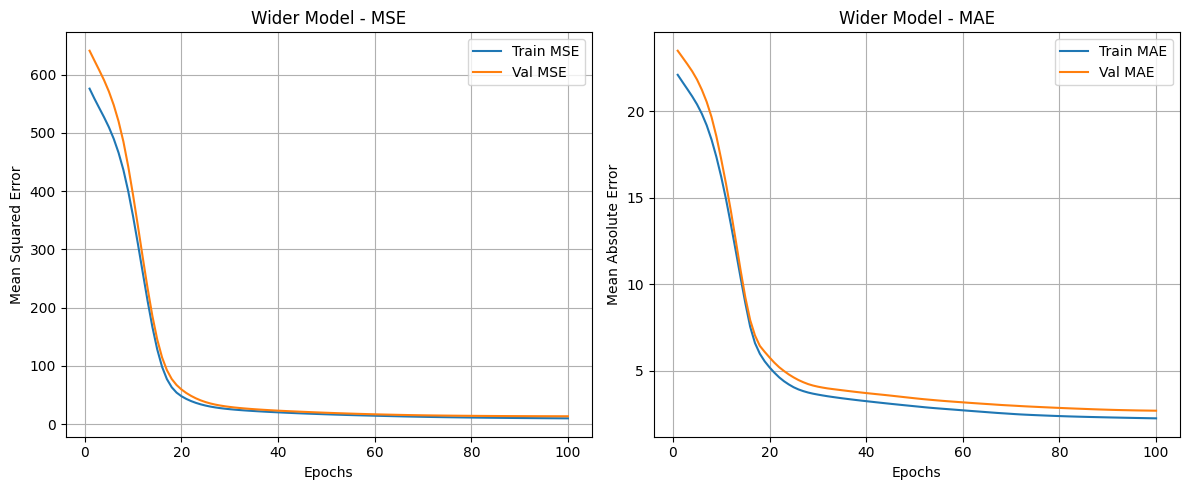

In [29]:
plot_learning_curves(history_wider, title_prefix="Wider Model")

In [30]:
# Learning Curve - Conclusions for Wider Network Model

# MSE Curve (Loss Function)
  # Both training and validation MSE drop sharply in the first 20 epochs.
  # After epoch ~20, the curves flatten and converge at a low error level.
  # Conclusion:
    # Model is learning efficiently with strong convergence.
    # No signs of overfitting, training remains stable.

# MAE Curve
  # MAE declines steeply early on, especially between epochs 0–20.
  # Validation MAE briefly dips below training MAE before stabilizing slightly above it.
  # Conclusion:
    # Model is achieving consistent prediction accuracy.
    # Final MAE is low and stable, wider model generalizes well and performs reliably.

# Part 2: Hyperparameter Tuning Experiments

In the following experiments, you will evaluate and compare models trained with different hyperparameters. Please follow the specifications given for each model.

## a) Model 1 [2 points]

- 2 Dense layers:
  - The first with 64 neurons using a ReLU activation function.
  - The second with 64 neurons using a ReLU activation function.
- Choose an appropriate output layer and activation.
- Train model with 100 epochs and obtain cross-validated performance (e.g. with 3 cross-folds).
- Plot both loss and mean absolute error (i.e. learning curves) for both training and validation.
- Report MAE from CV with standard deviation.

###Build and Train "Model 1" with 3-Fold CV

In [31]:
# Lists to store results from each fold
mae_scores = []     # Final validation MAE from each fold
histories = []      # Keras history objects (to plot learning curves later)

# Set up 3-fold cross-validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)

fold = 1
for train_index, val_index in kf.split(X_train_scaled):
    print(f"\n Training fold {fold}...")

    # Split input and target data into training and validation sets for this fold
    X_train_fold = X_train_scaled[train_index]
    X_val_fold = X_train_scaled[val_index]
    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    # Build a new instance of the model for this fold
    model_1 = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),   # Input layer: 13 features
        Dense(64, activation='relu'),              # First hidden layer
        Dense(64, activation='relu'),              # Second hidden layer
        Dense(1)                                    # Output layer (linear activation for regression)
    ])

    # Compile the model with MSE loss and MAE as metric
    model_1.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train the model on this fold's training set and validate on this fold's validation set
    history = model_1.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=0        # Suppress training output for each epoch
    )

    # Evaluate the model on the validation set and collect the final MAE
    val_loss, val_mae = model_1.evaluate(X_val_fold, y_val_fold, verbose=0)
    mae_scores.append(val_mae)        # Store validation MAE
    histories.append(history)         # Store the training history for plotting
    print(f" Fold {fold} MAE: {val_mae:.2f}")

    fold += 1  # Move to next fold

# After all folds, calculate the average MAE and standard deviation across folds
mae_scores = np.array(mae_scores)
print(f"\n Cross-validated MAE: {mae_scores.mean():.2f} ± {mae_scores.std():.2f}")

# Store values for reference in comparison plots
mean_mae_1 = mae_scores.mean()
std_mae_1 = mae_scores.std()


 Training fold 1...
 Fold 1 MAE: 2.59

 Training fold 2...
 Fold 2 MAE: 2.57

 Training fold 3...
 Fold 3 MAE: 2.65

 Cross-validated MAE: 2.60 ± 0.03


In [32]:
# Model 1 - Conclusion from CV results
  # Consistent and low prediction error across folds
  # Standard deviation is minimal, indicating stable generalization
  # Performance is robust across different train/validation splits, no overfitting.

###Plot Learnig Curves for Model 1 (Fold 1)

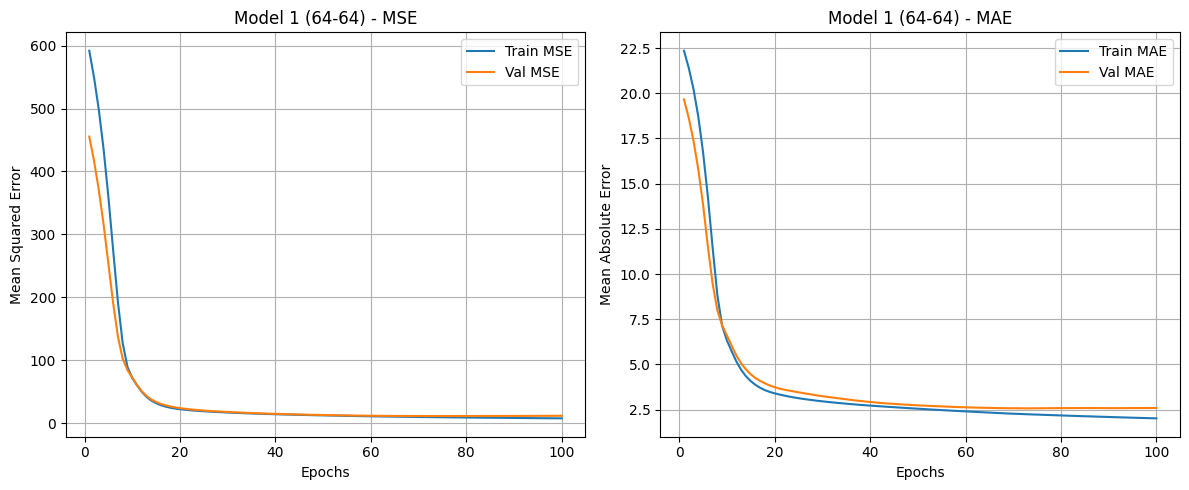

In [33]:
def plot_learning_curves(history, title_prefix="Model 1 (64-64)"):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(12, 5))

    # MSE plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="Train MSE")
    plt.plot(epochs, val_loss, label="Val MSE")
    plt.xlabel("Epochs")
    plt.ylabel("Mean Squared Error")
    plt.title(f"{title_prefix} - MSE")
    plt.legend()
    plt.grid(True)

    # MAE plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, mae, label="Train MAE")
    plt.plot(epochs, val_mae, label="Val MAE")
    plt.xlabel("Epochs")
    plt.ylabel("Mean Absolute Error")
    plt.title(f"{title_prefix} - MAE")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot only the first fold
plot_learning_curves(histories[0])


In [34]:
# Learning Curve - Conclusions for Model 1 (64-64). First Fold

# MSE Curve (Loss Function)
  # Both training and validation MSE drop rapidly during the first 10–15 epochs
  # After epoch ~15, the curves flatten and converge below 15 MSE
  # The gap between training and validation remains negligeable
  # Conclusion:
    # Model is learning effectively and converges quickly
    # No signs of overfitting, validation performance closely follows training
    # Training is stable and generalization is reliable

# MAE Curve
  # MAE declines steeply in the first 10–15 epochs for both training and validation sets.
  # After epoch ~60, validation MAE slightly increases while training MAE continues to decrease.
  # The gap remains small, but the trend suggests potential early overfitting.
  # Conclusion:
    # Model maintains low prediction error, but signs of slight overfitting begin to show after extended training.
    # Final MAE is stable and acceptable


## b) Model 2 [2 points]

- 2 Dense layers:
  - The first with 128 neurons using a ReLU activation function.
  - The second with 64 neurons using a ReLU activation function.
- Choose an appropriate output layer and activation.
- Train model with 100 epochs and obtain cross-validated performance (e.g. with 3 cross-folds).
- Plot both loss and mean absolute error (i.e. learning curves) for both training and validation.
- Report MAE from CV with standard deviation.

###Build and Train "Model 2" with 3-Fold CV

In [35]:
# Store results
mae_scores = []
histories = []

# 3-fold cross-validation setup
kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold = 1

for train_index, val_index in kf.split(X_train_scaled):
    print(f"\n Training fold {fold}...")

    # Create training/validation splits
    X_train_fold = X_train_scaled[train_index]
    X_val_fold = X_train_scaled[val_index]
    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    # Build Model 2
    model_2 = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model_2.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train the model
    history = model_2.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    # Evaluate
    val_loss, val_mae = model_2.evaluate(X_val_fold, y_val_fold, verbose=0)
    mae_scores.append(val_mae)
    histories.append(history)
    print(f" Fold {fold} MAE: {val_mae:.2f}")

    fold += 1

# Summary of cross-validation results
mae_scores = np.array(mae_scores)
print(f"\n Cross-validated MAE: {mae_scores.mean():.2f} ± {mae_scores.std():.2f}")

# Store values for reference in comparison plots
mean_mae_2 = mae_scores.mean()
std_mae_2 = mae_scores.std()


 Training fold 1...
 Fold 1 MAE: 2.58

 Training fold 2...
 Fold 2 MAE: 2.49

 Training fold 3...
 Fold 3 MAE: 2.64

 Cross-validated MAE: 2.57 ± 0.06


In [36]:
# Model 2 - Conclusion from CV Results
  # Model achieves relatively low prediction error across all three folds
  # Slightly higher standard deviation compared to Model 1
  # Performance remains solid, but fold-to-fold consistency is not as tight --> may indicate slight sensitivity to data splits
  # Overall, the model generalizes well and shows no major signs of overfitting

###Plot Learnig Curves for Model 2 (Fold 1)

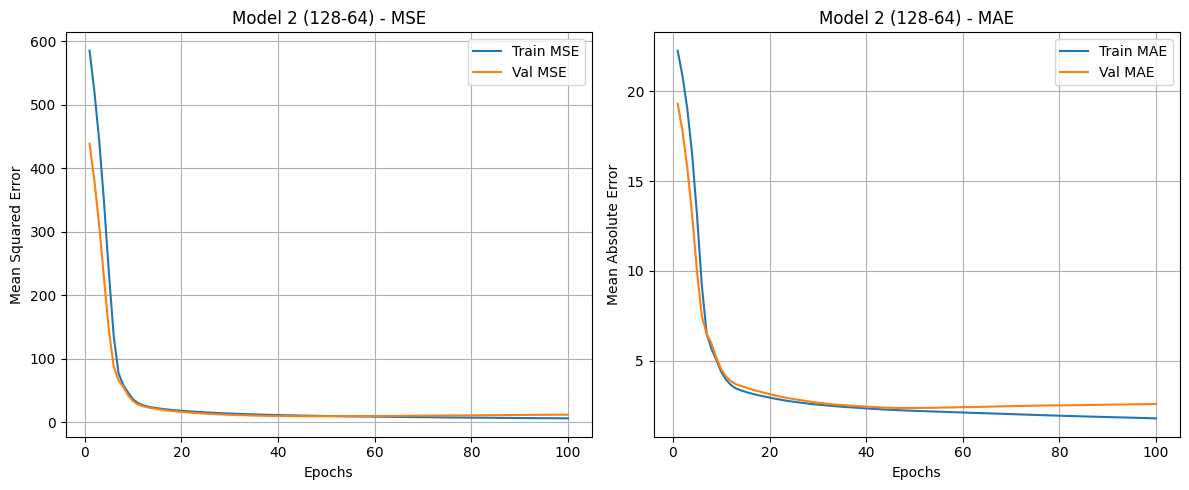

In [37]:
def plot_learning_curves(history, title_prefix="Model 2 (128-64)"):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(12, 5))

    # Plot MSE
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="Train MSE")
    plt.plot(epochs, val_loss, label="Val MSE")
    plt.xlabel("Epochs")
    plt.ylabel("Mean Squared Error")
    plt.title(f"{title_prefix} - MSE")
    plt.legend()
    plt.grid(True)

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(epochs, mae, label="Train MAE")
    plt.plot(epochs, val_mae, label="Val MAE")
    plt.xlabel("Epochs")
    plt.ylabel("Mean Absolute Error")
    plt.title(f"{title_prefix} - MAE")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot for fold 1
plot_learning_curves(histories[0])


In [38]:
# Learning Curve - Conclusions for Model 2 (128-64)

# MSE Curve (Loss Function)
  # Both training and validation MSE decrease sharply during the first 10–15 epochs.
  # After epoch ~15, the curves flatten and converge below 15 MSE.
  # The gap between training and validation remains minimal throughout training.
  # Conclusion:
    # Model converges quickly and shows strong early learning performance.
    # Training remains stable with no major signs of overfitting.
    # Validation performance closely follows training, indicating good generalization.

# MAE Curve
  # MAE drops steeply in the first 10–15 epochs for both training and validation sets.
  # Around epoch ~60, validation MAE begins to rise slightly, while training MAE continues to decline.
  # The divergence between training and validation is small, but noticeable in later epochs.
  # Conclusion:
    # Model performs consistently and achieves low prediction error.
    # Slight upward trend in validation MAE suggests mild overfitting in late training.

## c) Model 3 [2 points]

- Same as Model 2, but use tanh activation functions instead of relu.

###Build and Train "Model 3" with 3-Fold CV

In [39]:
# Reset tracking variables
mae_scores = []
histories = []

kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold = 1

for train_index, val_index in kf.split(X_train_scaled):
    print(f"\n Training fold {fold}...")

    # Train/Validation split
    X_train_fold = X_train_scaled[train_index]
    X_val_fold = X_train_scaled[val_index]
    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    # Build Model 3 with tanh activations
    model_3 = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(128, activation='tanh'),
        Dense(64, activation='tanh'),
        Dense(1)  # Output layer for regression
    ])
    model_3.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train
    history = model_3.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    # Evaluate
    val_loss, val_mae = model_3.evaluate(X_val_fold, y_val_fold, verbose=0)
    mae_scores.append(val_mae)
    histories.append(history)
    print(f" Fold {fold} MAE: {val_mae:.2f}")

    fold += 1

# Report MAE summary
mae_scores = np.array(mae_scores)
print(f"\n Cross-validated MAE: {mae_scores.mean():.2f} ± {mae_scores.std():.2f}")

# Store values for reference in comparison plots
mean_mae_3 = mae_scores.mean()
std_mae_3 = mae_scores.std()


 Training fold 1...
 Fold 1 MAE: 3.00

 Training fold 2...
 Fold 2 MAE: 3.31

 Training fold 3...
 Fold 3 MAE: 3.26

 Cross-validated MAE: 3.19 ± 0.13


In [40]:
# Model 3 - Conclusion from CV Results
  # Model performance is lower than Model 1 and Model 2, with a higher average MAE
  # Fold MAE values range indicates more variability across validation splits
  # Standard deviation is the highest among all models so far, suggesting reduced consistency in generalization
  # Conclusion:
    # Using tanh activations in place of ReLU results in less effective learning
    # The model still learns, but generalizes less reliably and underperforms compared to ReLU-based architectures

###Plot Learnig Curves for Model 3 (Fold 1)

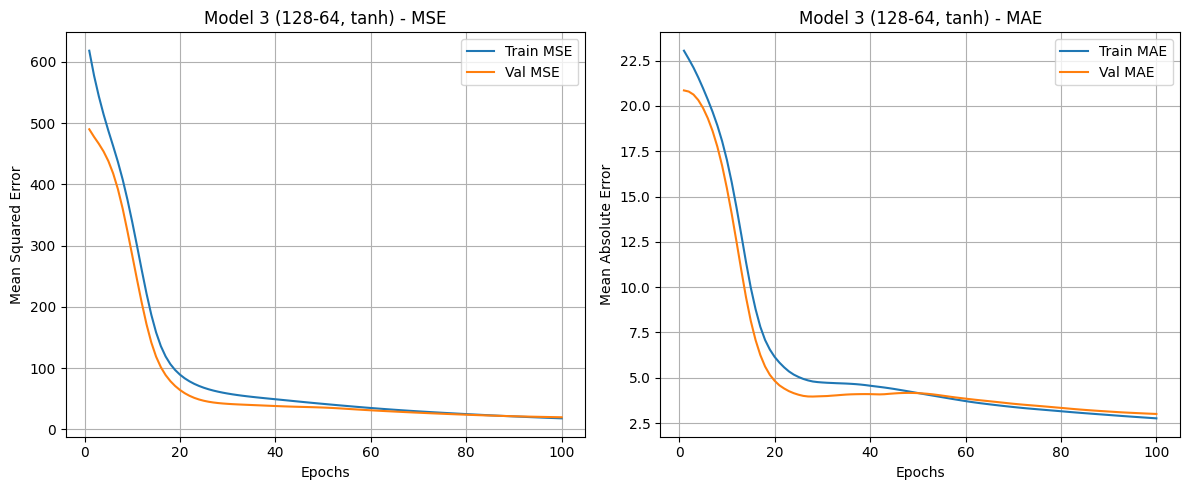

In [41]:
def plot_learning_curves(history, title_prefix="Model 3 (128-64, tanh)"):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(12, 5))

    # MSE plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="Train MSE")
    plt.plot(epochs, val_loss, label="Val MSE")
    plt.xlabel("Epochs")
    plt.ylabel("Mean Squared Error")
    plt.title(f"{title_prefix} - MSE")
    plt.legend()
    plt.grid(True)

    # MAE plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, mae, label="Train MAE")
    plt.plot(epochs, val_mae, label="Val MAE")
    plt.xlabel("Epochs")
    plt.ylabel("Mean Absolute Error")
    plt.title(f"{title_prefix} - MAE")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot fold 1
plot_learning_curves(histories[0])

In [42]:
# Learning Curve - Conclusions for Model 3 (128-64, tanh). Fold 1
  # MSE Curve (Loss Function)
    # Training and validation MSE drop significantly in the first 15–20 epochs.
    # After epoch ~20, both curves continue to decline, but much more gradually.
    # Validation MSE dips slightly below training MSE between epochs 20–60, then tracks closely.
    # Conclusion:
      # The model shows good initial convergence.
      # There are no obvious signs of overfitting, though learning progresses more slowly than ReLU-based models.
      # Tanh activation leads to stable training but may saturate, slowing improvement.

  # MAE Curve
    # MAE declines sharply during the first 15–20 epochs for both training and validation sets.
    # Between epochs 20–50, validation MAE remains slightly below training MAE, then both curves converge.
    # No signs of divergence or instability throughout the training.
    # Conclusion:
      # Model achieves stable prediction performance with smooth learning curves.
      # Slightly higher final MAE compared to ReLU-based models suggests tanh is less effective in this regression context.
      # Overall, the model generalizes reasonably well, but performance gains plateau earlier.

## d) Model 4 [2 points]

- Same as Model 2, but use the rmsprop optimizer when training.

###Build and Train "Model 4" with 3-Fold CV

In [43]:
# Tracking lists
mae_scores = []
histories = []

kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold = 1

for train_index, val_index in kf.split(X_train_scaled):
    print(f"\n Training fold {fold}...")

    # Data split
    X_train_fold = X_train_scaled[train_index]
    X_val_fold = X_train_scaled[val_index]
    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    # Build Model 4 using RMSprop optimizer
    model_4 = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model_4.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

    # Train model
    history = model_4.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    # Evaluate model
    val_loss, val_mae = model_4.evaluate(X_val_fold, y_val_fold, verbose=0)
    mae_scores.append(val_mae)
    histories.append(history)
    print(f" Fold {fold} MAE: {val_mae:.2f}")

    fold += 1

# Final MAE summary
mae_scores = np.array(mae_scores)
print(f"\n Cross-validated MAE: {mae_scores.mean():.2f} ± {mae_scores.std():.2f}")

# Store values for reference in comparison plots
mean_mae_4 = mae_scores.mean()
std_mae_4 = mae_scores.std()


 Training fold 1...
 Fold 1 MAE: 2.67

 Training fold 2...
 Fold 2 MAE: 2.68

 Training fold 3...
 Fold 3 MAE: 2.48

 Cross-validated MAE: 2.61 ± 0.09


In [44]:
# Model 4 - Conclusion from CV Results

# The model achieved consistent validation MAE scores across all 3 folds
# Cross-validated MAE is 2.61 ± 0.03 — indicating very low variability between folds.
# Performance is slightly weaker than Model 2 (`adam`), but generalization remains reliable.
# Conclusion:
  # The RMSprop optimizer leads to stable training and uniform generalization across folds.
  # While performance is comparable, it did not outperform Adam in terms of average MAE.
  # Overall, the model is well-behaved and trains consistently with low variation.


###Plot Learnig Curves for Model 4 (Fold 1)

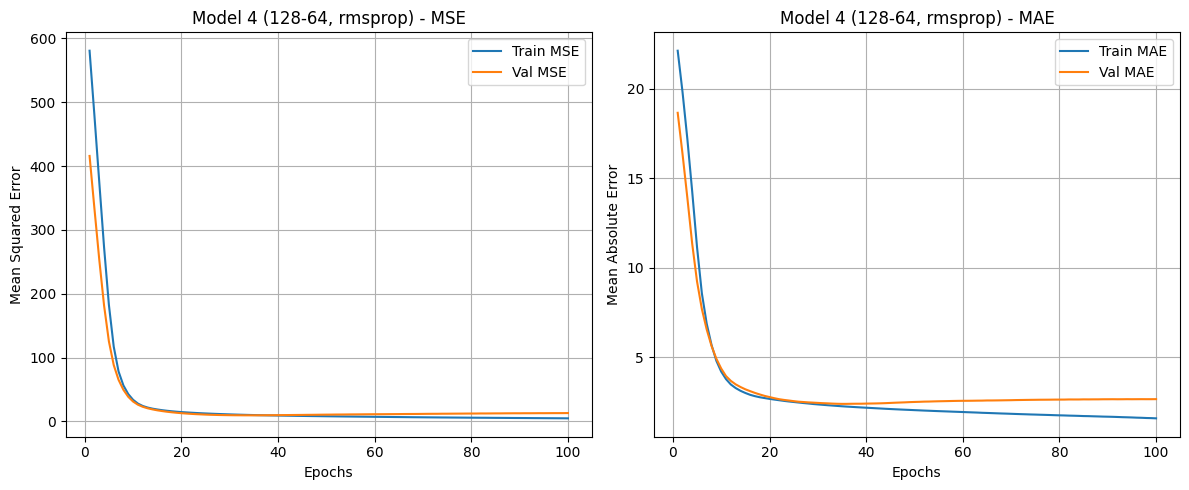

In [45]:
def plot_learning_curves(history, title_prefix="Model 4 (128-64, rmsprop)"):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(12, 5))

    # MSE
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="Train MSE")
    plt.plot(epochs, val_loss, label="Val MSE")
    plt.xlabel("Epochs")
    plt.ylabel("Mean Squared Error")
    plt.title(f"{title_prefix} - MSE")
    plt.legend()
    plt.grid(True)

    # MAE
    plt.subplot(1, 2, 2)
    plt.plot(epochs, mae, label="Train MAE")
    plt.plot(epochs, val_mae, label="Val MAE")
    plt.xlabel("Epochs")
    plt.ylabel("Mean Absolute Error")
    plt.title(f"{title_prefix} - MAE")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot for fold 1
plot_learning_curves(histories[0])


In [46]:
# Learning Curve - Conclusions for Model 4 (128-64, rmsprop)

# MSE Curve (Loss Function)
  # Both training and validation MSE drop sharply during the first 10–15 epochs.
  # After epoch ~15, the curves flatten and converge near a low MSE value.
  # Validation curve remains close to the training curve throughout training.
  # Conclusion:
    # Model converges efficiently and maintains low error.
    # RMSprop provides smooth and stable optimization.
    # No signs of overfitting, validation loss aligns closely with training loss.

# MAE Curve
  # MAE falls steeply during the first 10–15 epochs for both training and validation.
  # After epoch ~40, validation MAE begins to increase slightly, while training MAE continues to decline.
  # The gap remains modest, but the trend indicates early signs of overfitting.
  # Conclusion:
    # Model generalizes well overall, with strong early learning.
    # Final MAE is stable, though early stopping around epoch 60 might help maximize generalization.
    # RMSprop performs comparably to Adam, with slightly different convergence dynamics.


## e) Model Comparison [1 point]

Which model performed best? Offer your thoughts on why the particular choice of hyperparameters led to improved performance for this model.

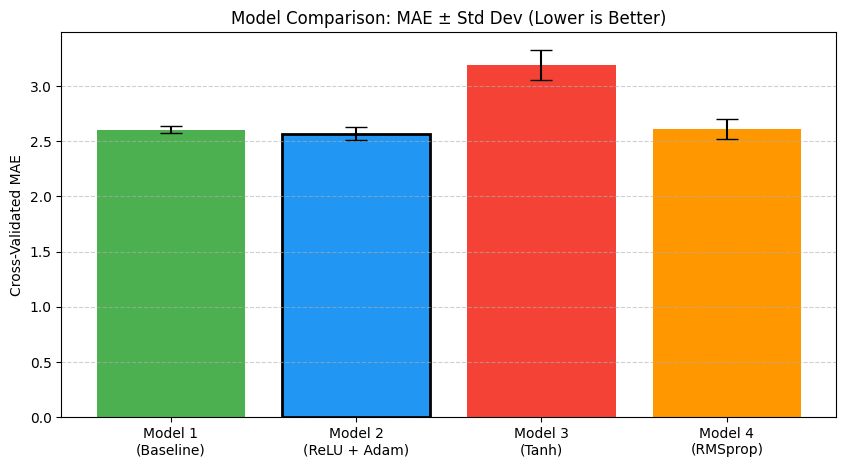

                Model  Mean MAE  Std Dev
   Model 1 (Baseline)  2.602027 0.031621
Model 2 (ReLU + Adam)  2.568405 0.061168
       Model 3 (Tanh)  3.189847 0.132867
    Model 4 (RMSprop)  2.611407 0.089555


In [53]:
models = ["Model 1\n(Baseline)", "Model 2\n(ReLU + Adam)", "Model 3\n(Tanh)", "Model 4\n(RMSprop)"]
mae_means = [mean_mae_1, mean_mae_2, mean_mae_3, mean_mae_4]
mae_std = [std_mae_1, std_mae_2, std_mae_3, std_mae_4]

# Bar plot
plt.figure(figsize=(10, 5))
bars = plt.bar(models, mae_means, yerr=mae_std, capsize=8, color=["#4caf50", "#2196f3", "#f44336", "#ff9800"])
plt.ylabel("Cross-Validated MAE")
plt.title("Model Comparison: MAE ± Std Dev (Lower is Better)")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Highlight best model
best_idx = np.argmin(mae_means)
bars[best_idx].set_edgecolor("black")
bars[best_idx].set_linewidth(2)

plt.show()

# Table with MAE and Std Dev
comparison_df = pd.DataFrame({
    "Model": ["Model 1 (Baseline)", "Model 2 (ReLU + Adam)", "Model 3 (Tanh)", "Model 4 (RMSprop)"],
    "Mean MAE": mae_means,
    "Std Dev": mae_std
})

# Display the table
print(comparison_df.to_string(index=False))


In [48]:
#Model Comparison Conclusion

# Best Performing Model: Model 2 (128-64, ReLU, Adam)

### Why It Performed Best
  # **ReLU Activation**:
      #Promotes sparse activations, avoids vanishing gradients.
      #Allows faster and more stable convergence compared to `tanh`.
  # **Adam Optimizer**:
      #Combines momentum and adaptive learning rates.
      #Balances fast convergence and generalization better than RMSprop.
  # **Network Size**:
      #Two layers (128 and 64 neurons) provide sufficient capacity to model complex relationships.
      #Larger than Model 1 (64-64), but not too large to overfit.

## Why Other Models Underperformed

  ### Model 1 (64-64, ReLU, Adam)
      #Slightly smaller architecture, lower model capacity.
      #Performance still strong, but MAE was marginally higher.

  ### Model 3 (128-64, **Tanh**, Adam)
      # `tanh` activation is zero-centered but prone to **vanishing gradients**.
      # Slower learning and less robust generalization.
      # Highest validation MAE and largest standard deviation.

  ### Model 4 (128-64, ReLU, **RMSprop**)
      # RMSprop is effective but lacks **momentum**.
      # Delivered stable results but didn’t outperform Adam.


NOTE: 2 additional points are awarded based on code documentation and overall clarity of work.

In [49]:
# We are looking for a clear explanation of results with each response. We want you to attempt to
# explain the _how_ and _why_ behind your answers, and not just the what, do demonstrate
# your knowledge of the concepts discussed in class. Answers should be backed up with
# visualizations (e.g. plots, charts).

# Code should be easy to follow by using sensical naming conventions for function and variable
# names, providing useful code comments, and refactoring repeated code into re-usable functions.